#EDA using Restaurant Branch Performance Dataset

NOTE: necessary observations are written after the code cells

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/IDRA/Day13_Restaurant_Branch_Performance_Dataset.csv')
df.head()

,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,...,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,4977.25,172,...,66766.77,27954.29,46554.90,20211.87,29.0,4.44,20.8,70.3,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,8998.30,285,...,157230.89,63816.59,96813.95,60416.94,27.9,4.56,31.3,70.7,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,10034.97,306,...,155811.96,54874.10,89888.91,65923.05,30.2,4.36,21.4,61.5,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,5095.84,198,...,80574.05,31429.44,53531.82,27042.23,21.7,4.65,22.9,40.4,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,6681.82,148,...,56579.89,21759.51,44376.25,12203.64,26.1,4.50,29.0,44.3,Clear,Combo Deal


In [3]:
df.shape

(350, 22)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         350 non-null    object 
 1   Date              350 non-null    object 
 2   Day               350 non-null    object 
 3   Month             350 non-null    object 
 4   Branch            350 non-null    object 
 5   Region            350 non-null    object 
 6   Store_Type        350 non-null    object 
 7   Staff_Count       350 non-null    int64  
 8   Marketing_Spend   350 non-null    float64
 9   Customers         350 non-null    int64  
 10  Orders            350 non-null    int64  
 11  Average_Bill      350 non-null    float64
 12  Revenue           350 non-null    float64
 13  Food_Cost         350 non-null    float64
 14  Operating_Cost    350 non-null    float64
 15  Profit            350 non-null    float64
 16  Avg_Delivery_Min  350 non-null    float64
 1

In [5]:
df.isnull().sum()

,0
Record_ID,0
Date,0
Day,0
Month,0
Branch,0
Region,0
Store_Type,0
Staff_Count,0
Marketing_Spend,0
Customers,0


Promotion column have 184 null values. These were to be checked before deciding how to handle them

In [6]:
df['Promotion'].value_counts(dropna=False)

,count
Promotion,
NaN,184
Weekend Offer,74
Combo Deal,59
Loyalty Offer,33


In [7]:
promotion = df['Promotion'].fillna('No promotion')
promotion.value_counts()

,count
Promotion,
No promotion,184
Weekend Offer,74
Combo Deal,59
Loyalty Offer,33


In [8]:
df.duplicated().sum()

np.int64(0)

##Summary & Descriptive Statistics

In [9]:
df.describe()

,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,11.957143,5516.347743,217.377143,187.054286,388.906371,86831.799657,31807.545114,56621.444486,30210.355171,26.098857,4.469314,27.740000,61.324571
std,4.338261,2050.906967,56.722524,50.558371,82.488196,36644.453901,13896.888942,18467.842215,19508.592192,4.388125,0.198258,4.903148,13.757322
min,5.000000,725.350000,77.000000,71.000000,180.000000,20540.760000,7262.010000,20782.380000,-6924.680000,13.900000,3.760000,14.500000,25.000000
25%,9.000000,4339.727500,180.250000,155.000000,337.315000,61261.717500,22326.662500,43797.670000,16915.492500,22.800000,4.320000,24.400000,51.325000
50%,11.000000,5393.370000,213.000000,182.500000,383.485000,79766.880000,28861.325000,53723.025000,26873.870000,26.100000,4.470000,27.800000,61.650000
75%,15.000000,6748.502500,255.750000,218.750000,441.765000,102976.185000,38370.370000,63961.227500,39823.742500,29.075000,4.600000,31.000000,70.375000
max,24.000000,11784.960000,360.000000,334.000000,623.280000,194018.920000,75946.590000,111489.140000,89096.190000,38.300000,4.960000,43.500000,95.000000


- Branches have customers between 77 and 360
- Profit has a negative value as minimum; could mean that there are branches suffering a loss

In [10]:
df.groupby('Branch')[['Revenue','Profit']].mean()

,Revenue,Profit
Branch,,
Bengaluru,90732.118696,31890.914783
Delhi,87573.869375,31385.295313
Hyderabad,88804.899535,31402.976977
Jaipur,86746.158333,30469.703333
Kochi,85574.617917,28902.036250
Mumbai,80779.248864,26580.988409
Pune,88107.489730,31265.571892
Srinagar,86746.472885,30302.915769


The branch with the highest average revenue performs better in terms of profit generation, that is Bengaluru

In [11]:
df.groupby('Region')['Profit'].mean()

,Profit
Region,
North,30625.960833
South,30690.568102
West,28720.859877


- South region has the highest average profit generated
- South and North regions have a close difference
- West region generates the least profit, according to the given dataset

##Distribution Analysis Graphs

Numerical features (Customers, Revenue, Profit, Marketing_Spend, Customer_Rating, etc) are shown in histograms

In [12]:
df['Customers'].unique()

array([172, 285, 306, 198, 148, 214, 247, 230, 173, 328, 145, 178, 120,
       175, 315, 259, 151, 168, 179, 258, 201, 184, 360,  94, 171,  95,
       235, 164, 277, 195, 239, 189, 117, 282, 143, 197, 159, 218, 121,
       226, 222, 220, 286, 202, 132, 192, 228, 227, 176, 283, 264, 279,
       188, 133, 251, 255, 155, 296, 130, 314, 200, 240, 354, 223, 233,
       321, 262, 221, 185, 182, 207, 123, 236, 153, 301, 206, 272, 102,
       149, 183, 303, 191, 266, 193, 241, 219, 269, 300, 118, 140, 268,
       340, 136, 237, 181, 256, 332, 142, 284, 216, 224, 152, 320, 135,
       257, 238, 297, 318, 161, 111, 137, 271, 180, 215, 253, 246, 345,
       203, 270, 150, 194, 212, 274, 347, 250, 322, 165, 209, 249, 329,
       234, 265, 157, 187, 248, 177, 163, 267, 204, 131, 319, 245, 295,
       261, 170, 291, 210, 158, 280, 144, 339, 205, 290, 106, 289, 243,
       229, 169, 313, 160, 323, 232, 190, 263, 288, 208,  77, 252, 199,
       211, 156, 275, 109, 231, 141, 304, 196, 225])

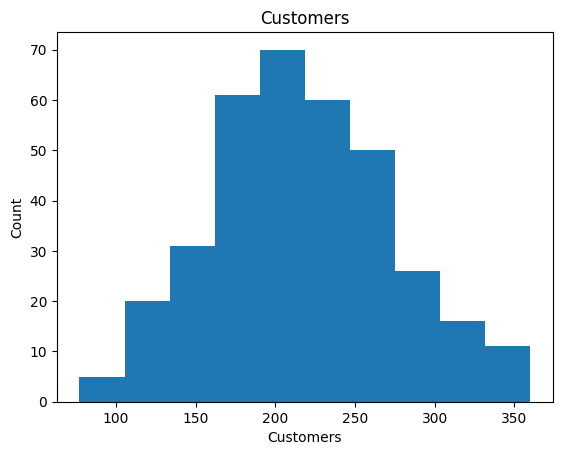

In [13]:
df['Customers'].plot(kind='hist')
plt.title('Customers')
plt.xlabel('Customers')
plt.ylabel('Count')
plt.show()

Most branches have around 190 to 260 customers per day

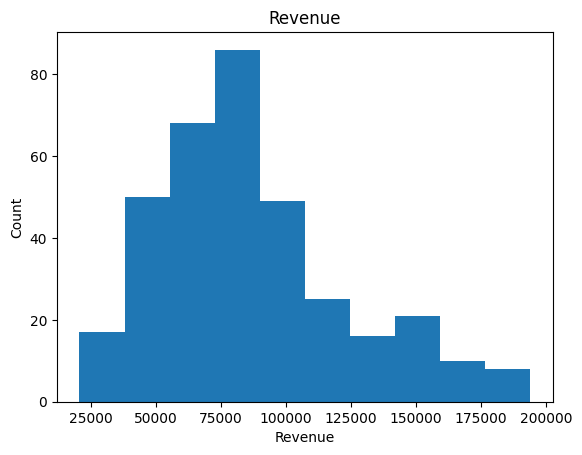

In [14]:
df['Revenue'].plot(kind='hist')
plt.title('Revenue')
plt.xlabel('Revenue')
plt.ylabel('Count')
plt.show()

- most revenue observations are between 50,000 to 1,00,000
- fewer observations ar higher revenue levels

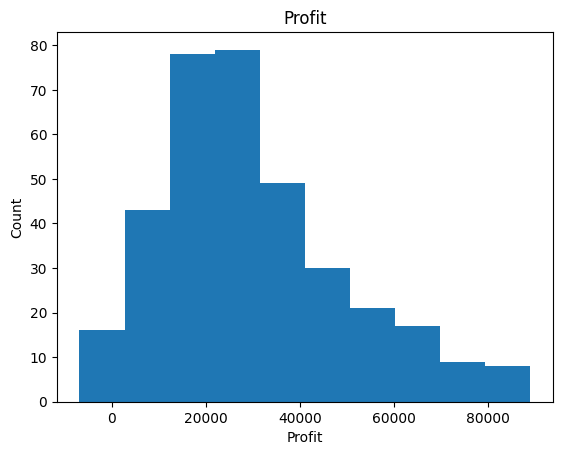

In [15]:
df['Profit'].plot(kind='hist')
plt.title('Profit')
plt.xlabel('Profit')
plt.ylabel('Count')
plt.show()

- There are negative profits, indicating some branches are at loss
- most profits are between 10,000 to 40,000

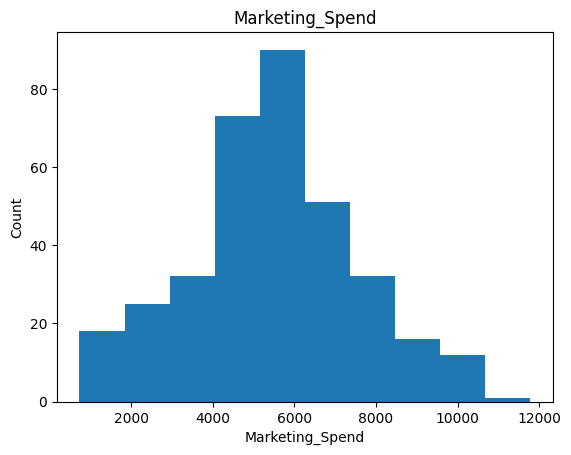

In [16]:
df['Marketing_Spend'].plot(kind='hist')
plt.title('Marketing_Spend')
plt.xlabel('Marketing_Spend')
plt.ylabel('Count')
plt.show()

most observations of the marketing spend is concenrated between 4,000 to 7,000

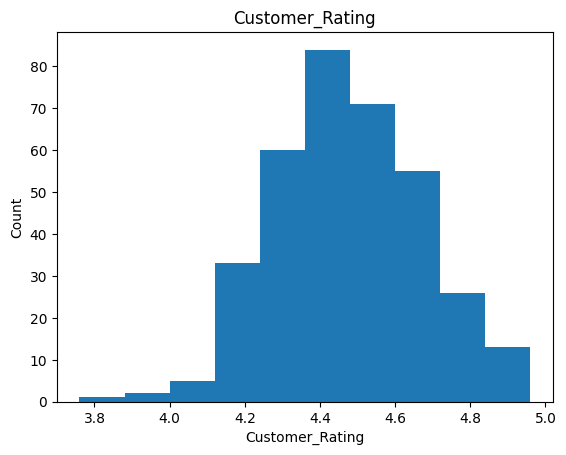

In [17]:
df['Customer_Rating'].plot(kind='hist')
plt.title('Customer_Rating')
plt.xlabel('Customer_Rating')
plt.ylabel('Count')
plt.show()

most rating are between 4.3 to 4.7, so most branches are fairly high review

For categorical columns (like Region, Store_Type, Promotion), bar charts are used

In [18]:
df['Region'].unique()

array(['North', 'West', 'South'], dtype=object)

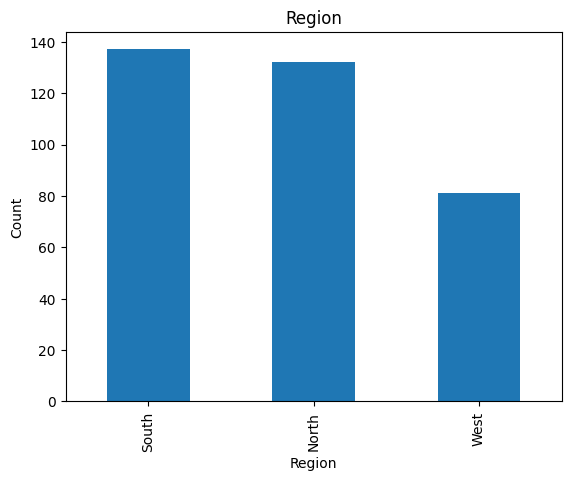

In [19]:
df['Region'].value_counts().plot(kind='bar')
plt.title('Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

from this observation, it can be understood that South has most observations with North closely following and West has the least

In [20]:
df['Store_Type'].unique()

array(['Express', 'Premium', 'Standard'], dtype=object)

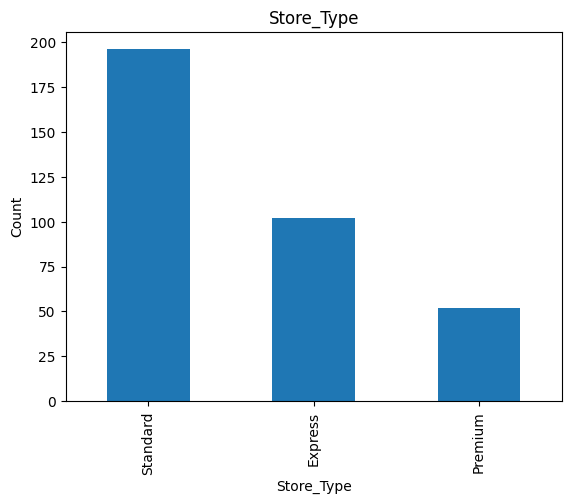

In [21]:
df['Store_Type'].value_counts().plot(kind='bar')
plt.title('Store_Type')
plt.xlabel('Store_Type')
plt.ylabel('Count')
plt.show()

Standard stores have most observations, while Premium stores consitute the smallest group

In [22]:
df['Promotion'].unique()

array([nan, 'Loyalty Offer', 'Combo Deal', 'Weekend Offer'], dtype=object)

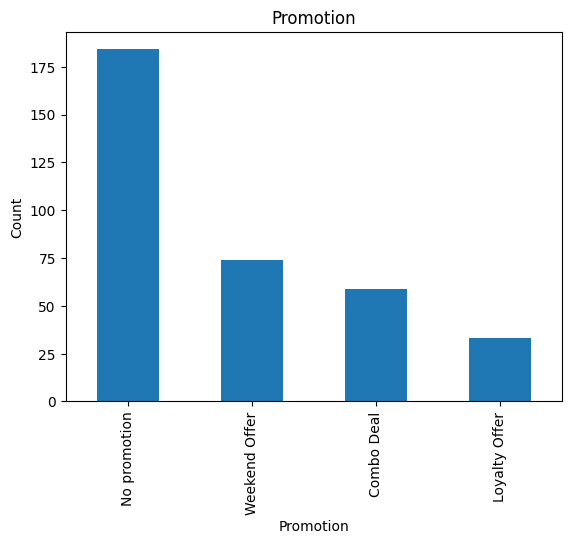

In [23]:
promotion.value_counts().plot(kind='bar')
plt.title('Promotion')
plt.xlabel('Promotion')
plt.ylabel('Count')
plt.show()

- most observations did not have any promotion
- the most frquently used promotion is the weekend offer

#Branch wise Analysis

In [24]:
print(df.groupby('Branch').agg({
    'Customers': 'mean',
    'Revenue': 'mean',
    'Profit': 'mean',
    'Marketing_Spend': 'mean',
    'Avg_Delivery_Min': 'mean',
    'Customer_Rating': 'mean'
    })
)

            Customers       Revenue        Profit  Marketing_Spend  \
Branch                                                               
Bengaluru  227.500000  90732.118696  31890.914783      5413.928478   
Delhi      213.968750  87573.869375  31385.295313      5762.632500   
Hyderabad  220.790698  88804.899535  31402.976977      5455.148372   
Jaipur     223.270833  86746.158333  30469.703333      5356.641458   
Kochi      209.062500  85574.617917  28902.036250      5660.430000   
Mumbai     213.772727  80779.248864  26580.988409      5580.095682   
Pune       214.918919  88107.489730  31265.571892      5590.567568   
Srinagar   214.730769  86746.472885  30302.915769      5413.668077   

           Avg_Delivery_Min  Customer_Rating  
Branch                                        
Bengaluru         26.563043         4.465652  
Delhi             25.693750         4.485625  
Hyderabad         25.518605         4.469535  
Jaipur            26.583333         4.468958  
Kochi            

branch with
- highest customer count: Bengaluru
- highest revenue: Bengaluru
- highest profit: Bengaluru
- lowest delivery time: Hyderabad
- highest rating: Pune

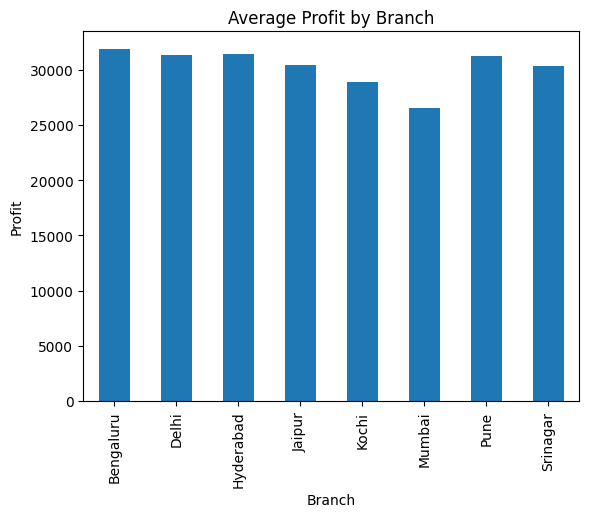

In [25]:
df.groupby('Branch')['Profit'].mean().plot(kind='bar')
plt.title('Average Profit by Branch')
plt.xlabel('Branch')
plt.ylabel('Profit')
plt.show()

According to the average profit produced by each branch, Bengaluru takes the top spot

#Region wise Analysis

In [26]:
print(df.groupby('Region').agg({
    'Customers': 'mean',
    'Revenue': 'mean',
    'Profit': 'mean',
    'Marketing_Spend': 'mean',
    'Avg_Delivery_Min': 'mean',
    'Customer_Rating': 'mean'
    })
)

         Customers       Revenue        Profit  Marketing_Spend  \
Region                                                            
North   217.651515  86946.939470  30625.960833      5477.528561   
South   218.934307  88320.217518  30690.568102      5513.231606   
West    214.296296  84126.716914  28720.859877      5584.879136   

        Avg_Delivery_Min  Customer_Rating  
Region                                     
North          26.125758         4.477424  
South          25.982482         4.450803  
West           26.251852         4.487407  


region with
- highest customer count: South
- highest revenue: South
- highest profit: South
- lowest delivery time: South
- highest rating: West

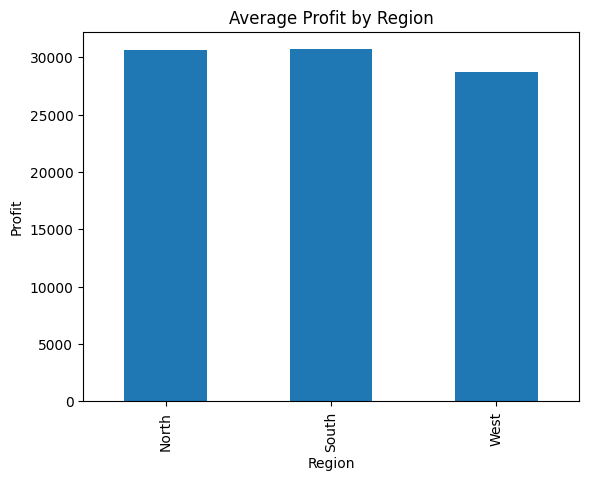

In [27]:
df.groupby('Region')['Profit'].mean().plot(kind='bar')
plt.title('Average Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()

According to the customer count and revenue & profit produced, South performs the best, though West got the highest customer rating

#Store Type wise Analysis

In [28]:
print(df.groupby('Store_Type').agg({
    'Customers': 'mean',
    'Revenue': 'mean',
    'Profit': 'mean',
    'Marketing_Spend': 'mean',
    'Avg_Delivery_Min': 'mean',
    'Customer_Rating': 'mean'
})
)

             Customers        Revenue        Profit  Marketing_Spend  \
Store_Type                                                             
Express     161.294118   52327.164804  12742.137941      5122.663922   
Premium     298.730769  152867.313269  62890.235385      8065.562692   
Standard    224.979592   87268.667245  30630.785714      5044.901684   

            Avg_Delivery_Min  Customer_Rating  
Store_Type                                     
Express            26.171569         4.465000  
Premium            26.400000         4.458654  
Standard           25.981122         4.474388  


Store type with
- highest customer count: Premium
- highest revenue produced: Premium
- highest profit produced: Premium
- lowest delivery time: Standard
- highest customer rating: Standard

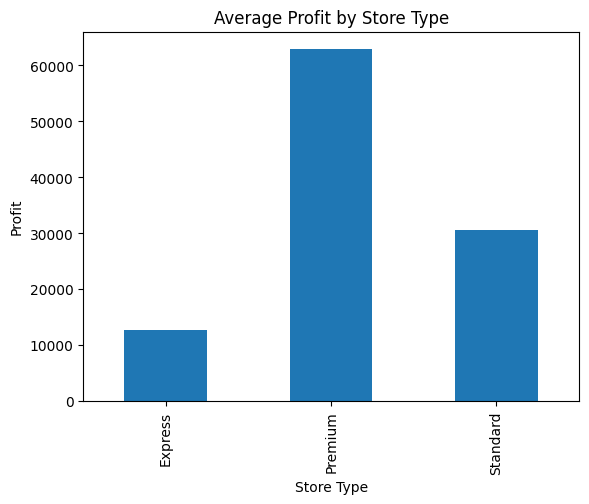

In [29]:
df.groupby('Store_Type')['Profit'].mean().plot(kind='bar')
plt.title('Average Profit by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Profit')
plt.show()

Premium stores have the highest profit among the different store types

#Correlation Analysis

##Customer & Revenue

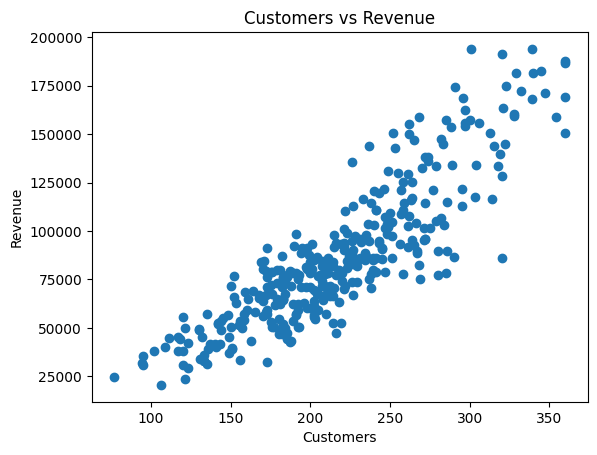


Correlation between Customers & Revenue:  0.8763608566981173


In [30]:
plt.scatter(df['Customers'], df['Revenue'])
plt.title('Customers vs Revenue')
plt.xlabel('Customers')
plt.ylabel('Revenue')
plt.show()

print("\nCorrelation between Customers & Revenue: ", df['Customers'].corr(df['Revenue']))

Points are generally move upward from left to right, fairly close to an upward trend. With the plot and calculated correlation, it indicates a strong positive relationship

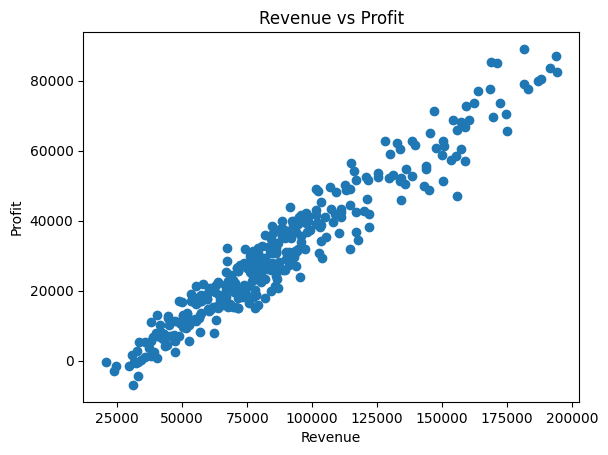


Correlation between Revenue & Profit:  0.9668312679776001


In [31]:
plt.scatter(df['Revenue'], df['Profit'])

plt.title('Revenue vs Profit')
plt.xlabel('Revenue')
plt.ylabel('Profit')
plt.show()

print("\nCorrelation between Revenue & Profit: ", df['Revenue'].corr(df['Profit']))

Points form a clear upward pattern. Along with the correlation value, it is clear that profit and revenue has a very strong positive correlation

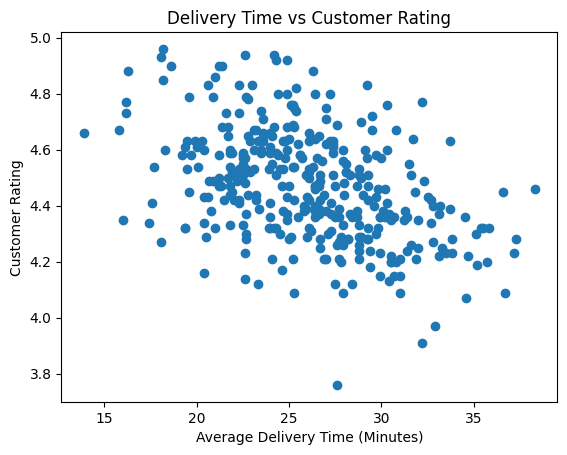


Correlation between Delivery Time & Customer Rating:  -0.4369837520470665


In [32]:
plt.scatter(df['Avg_Delivery_Min'], df['Customer_Rating'])

plt.title('Delivery Time vs Customer Rating')
plt.xlabel('Average Delivery Time (Minutes)')
plt.ylabel('Customer Rating')
plt.show()

print("\nCorrelation between Delivery Time & Customer Rating: ", df['Avg_Delivery_Min'].corr(df['Customer_Rating']))

The points are scattered, indicating a downward pattern. Observing the correlation score, it can be understood that with higher delivery time the customer rating goes down. So, the relation between delivery time and customer rating is a moderate negative relationship

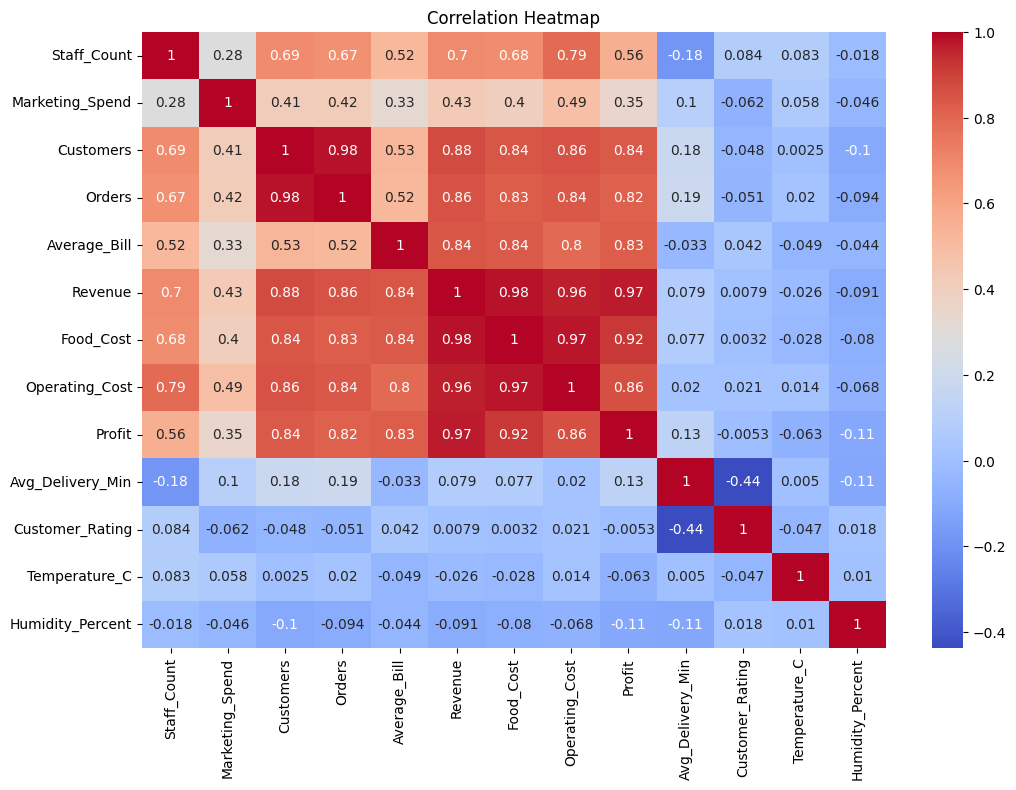

In [33]:
corr = df.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(12, 8))

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

from the correlation matrix, we can observe that
- there is a very strong positive relation between the customer count and no. of orders (0.98)
- very strong relation between profit and revenue (0.97)
- branches hving more food costs generates more revenue (0.98)
- branches with low staff count takes more delivery time, indicating a negative correlation (-0.18)
- moderate negative relation between delivery time and customer rating (-0.44) shows that with greater delivery time, the rating goes down
- the diagonals of the matrix has the correlation value of 1 as the features are perfectly correlated with itself